# Vietnamese Product Review Classification
**IT4930 - Data Science - Nhóm 21**

Phân loại phản ánh tiêu cực của người dùng thành 4 nhóm:
- **0 = Quality** – Chất lượng sản phẩm
- **1 = Service** – Dịch vụ khách hàng  
- **2 = Packing** – Đóng gói
- **3 = Shipping** – Vận chuyển

### Chuẩn bị trước khi chạy
1. Upload lên Kaggle 1 dataset gồm 2 file:
   - `comments_merged_single_label_augmented.csv`
   - `vietnamese-stopwords.txt`
2. Thay `vn-review-data` trong các cell dưới bằng tên dataset của bạn

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lcminhc/tiki-comments-single-label-augmented/vietnamese-stopwords.txt
/kaggle/input/datasets/lcminhc/tiki-comments-single-label-augmented/comments_merged_single_label_augmented.csv


In [2]:
print('Environment ready.')

Environment ready.


In [3]:
import re
import regex
import string
import unicodedata
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-06-11 18:16:10.509767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781201770.534944     114 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781201770.543161     114 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781201770.563045     114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781201770.563074     114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781201770.563077     114 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
  import os
  for dirpath, _, files in os.walk('/kaggle/input'):
      for f in files:
          print(os.path.join(dirpath, f))

/kaggle/input/datasets/lcminhc/tiki-comments-single-label-augmented/vietnamese-stopwords.txt
/kaggle/input/datasets/lcminhc/tiki-comments-single-label-augmented/comments_merged_single_label_augmented.csv


## Tiền Xử Lý Văn Bản Tiếng Việt

In [6]:
# ============================================================
# VIETNAMESE TEXT PREPROCESSING
# Inline từ preprocessing.py — đổi path stopwords sang Kaggle
# ============================================================

DATASET_PATH = '/kaggle/input/datasets/lcminhc/tiki-comments-single-label-augmented'

with open(f'{DATASET_PATH}/vietnamese-stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = f.read().splitlines()
    stopwords = [i for i in stopwords if i.find(' ') == -1]

bang_nguyen_am = [['a', 'à', 'á', 'ả', 'ã', 'ạ', 'a'],
                  ['ă', 'ằ', 'ắ', 'ẳ', 'ẵ', 'ặ', 'aw'],
                  ['â', 'ầ', 'ấ', 'ẩ', 'ẫ', 'ậ', 'aa'],
                  ['e', 'è', 'é', 'ẻ', 'ẽ', 'ẹ', 'e'],
                  ['ê', 'ề', 'ế', 'ể', 'ễ', 'ệ', 'ee'],
                  ['i', 'ì', 'í', 'ỉ', 'ĩ', 'ị', 'i'],
                  ['o', 'ò', 'ó', 'ỏ', 'õ', 'ọ', 'o'],
                  ['ô', 'ồ', 'ố', 'ổ', 'ỗ', 'ộ', 'oo'],
                  ['ơ', 'ờ', 'ớ', 'ở', 'ỡ', 'ợ', 'ow'],
                  ['u', 'ù', 'ú', 'ủ', 'ũ', 'ụ', 'u'],
                  ['ư', 'ừ', 'ứ', 'ử', 'ữ', 'ự', 'uw'],
                  ['y', 'ỳ', 'ý', 'ỷ', 'ỹ', 'ỵ', 'y']]

bang_ky_tu_dau = ['', 'f', 's', 'r', 'x', 'j']
nguyen_am_to_ids = {}
for i in range(len(bang_nguyen_am)):
    for j in range(len(bang_nguyen_am[i]) - 1):
        nguyen_am_to_ids[bang_nguyen_am[i][j]] = (i, j)


def chuan_hoa_unicode(text):
    return unicodedata.normalize('NFC', text)


def is_valid_vietnam_word(word):
    chars = list(word)
    nguyen_am_index = -1
    for index, char in enumerate(chars):
        x, y = nguyen_am_to_ids.get(char, (-1, -1))
        if x != -1:
            if nguyen_am_index == -1:
                nguyen_am_index = index
            else:
                if index - nguyen_am_index != 1:
                    return False
                nguyen_am_index = index
    return True


def chuan_hoa_dau_tu_tieng_viet(word):
    if not is_valid_vietnam_word(word):
        return word
    chars = list(word)
    dau_cau = 0
    nguyen_am_index = []
    qu_or_gi = False
    for index, char in enumerate(chars):
        x, y = nguyen_am_to_ids.get(char, (-1, -1))
        if x == -1:
            continue
        elif x == 9:
            if index != 0 and chars[index - 1] == 'q':
                chars[index] = 'u'
                qu_or_gi = True
        elif x == 5:
            if index != 0 and chars[index - 1] == 'g':
                chars[index] = 'i'
                qu_or_gi = True
        if y != 0:
            dau_cau = y
            chars[index] = bang_nguyen_am[x][0]
        if not qu_or_gi or index != 1:
            nguyen_am_index.append(index)
    if len(nguyen_am_index) < 2:
        if qu_or_gi:
            if len(chars) == 2:
                x, y = nguyen_am_to_ids.get(chars[1])
                chars[1] = bang_nguyen_am[x][dau_cau]
            else:
                x, y = nguyen_am_to_ids.get(chars[2], (-1, -1))
                if x != -1:
                    chars[2] = bang_nguyen_am[x][dau_cau]
                else:
                    chars[1] = bang_nguyen_am[5][dau_cau] if chars[1] == 'i' else bang_nguyen_am[9][dau_cau]
            return ''.join(chars)
        return word
    for index in nguyen_am_index:
        x, y = nguyen_am_to_ids[chars[index]]
        if x == 4 or x == 8:
            chars[index] = bang_nguyen_am[x][dau_cau]
            return ''.join(chars)
    if len(nguyen_am_index) == 2:
        if nguyen_am_index[-1] == len(chars) - 1:
            x, y = nguyen_am_to_ids[chars[nguyen_am_index[0]]]
            chars[nguyen_am_index[0]] = bang_nguyen_am[x][dau_cau]
        else:
            x, y = nguyen_am_to_ids[chars[nguyen_am_index[1]]]
            chars[nguyen_am_index[1]] = bang_nguyen_am[x][dau_cau]
    else:
        x, y = nguyen_am_to_ids[chars[nguyen_am_index[1]]]
        chars[nguyen_am_index[1]] = bang_nguyen_am[x][dau_cau]
    return ''.join(chars)


def chuan_hoa_dau_cau_tieng_viet(sentence):
    sentence = sentence.lower()
    words = sentence.split()
    for index, word in enumerate(words):
        cw = regex.sub(r'(^\p{P}*)([p{L}.]*\p{L}+)(\p{P}*$)', r'\1/\2/\3', word).split('/')
        if len(cw) == 3:
            cw[1] = chuan_hoa_dau_tu_tieng_viet(cw[1])
        words[index] = ''.join(cw)
    return ' '.join(words)


def get_lower(text):
    return text.lower().strip()


def chuan_hoa_cau(text):
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệóòỏõọôốồổỗộơớờởỡợíìỉĩịúùủũụưứừửữựýỳỷỹỵđ_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def remove_tag(text):
    return re.compile('<.*?>').sub(r'', text)


def remove_url(text):
    return re.compile(r'http\S+').sub(r'', text)


def remove_punc(text):
    for char in string.punctuation:
        text = text.replace(char, '')
    return text


def remove_stopW(text):
    return ' '.join(w for w in text.split() if w not in stopwords)


def remove_emoji(text):
    emoji_pattern = re.compile('['
        u'\U0001F600-\U0001F64F'
        u'\U0001F300-\U0001F5FF'
        u'\U0001F680-\U0001F6FF'
        u'\U0001F1E0-\U0001F1FF'
        u'\U00002702-\U000027B0'
        u'\U000024C2-\U0001F251'
        ']+', flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)


replace_list = {
    'ô kêi': ' ok ', 'okie': ' ok ', ' o kê ': ' ok ', 'okey': ' ok ', 'ôkê': ' ok ', 'oki': ' ok ',
    ' oke ': ' ok ', ' okay': ' ok ', 'okê': ' ok ',
    ' tks ': ' cám ơn ', 'thks': ' cám ơn ', 'thanks': ' cám ơn ', 'ths': ' cám ơn ', 'thank': ' cám ơn ',
    'kg ': ' không ', 'not': ' không ', ' kh ': ' không ', 'kô': ' không ', 'hok': ' không ',
    ' kp ': ' không phải ', ' kô ': ' không ', ' ko ': ' không ', ' k ': ' không ', 'khong': ' không ', ' hok ': ' không ',
    'he he': ' positive ', 'hehe': ' positive ', 'hihi': ' positive ', 'haha': ' positive ', 'hjhj': ' positive ',
    ' lol ': ' negative ', ' cc ': ' negative ', 'cute': ' dễ thương ', 'huhu': ' negative ',
    ' vs ': ' với ', 'wa': ' quá ', 'wá': ' quá', 'j': ' gì ', '"': ' ',
    ' sz ': ' cỡ ', 'size': ' cỡ ', ' đx ': ' được ', 'dk': ' được ', 'dc': ' được ', 'đk': ' được ',
    'đc': ' được ', 'authentic': ' chuẩn chính hãng ', ' aut ': ' chuẩn chính hãng ', ' auth ': ' chuẩn chính hãng ',
    'thick': ' positive ', 'store': ' cửa hàng ',
    'shop': ' cửa hàng ', 'sp': ' sản phẩm ', 'gud': ' tốt ', 'god': ' tốt ', 'wel done': ' tốt ',
    'good': ' tốt ', 'gút': ' tốt ', 'sấu': ' xấu ', 'gut': ' tốt ', ' tot ': ' tốt ', ' nice ': ' tốt ',
    'perfect': 'rất tốt', 'bt': ' bình thường ',
    'time': ' thời gian ', 'qá': ' quá ', ' ship ': ' giao hàng ', ' m ': ' mình ', ' mik ': ' mình ',
    'ể': 'ể', 'product': 'sản phẩm', 'quality': 'chất lượng', 'chat': ' chất ', 'excelent': 'hoàn hảo',
    'bad': 'tệ', 'fresh': ' tươi ', 'sad': ' tệ ',
    'date': ' hạn sử dụng ', 'hsd': ' hạn sử dụng ', 'quickly': ' nhanh ', 'quick': ' nhanh ',
    'fast': ' nhanh ', 'delivery': ' giao hàng ', ' síp ': ' giao hàng ',
    'beautiful': ' đẹp tuyệt vời ', ' tl ': ' trả lời ', ' r ': ' rồi ', ' shopE ': ' cửa hàng ',
    ' order ': ' đặt hàng ',
    'chất lg': ' chất lượng ', ' sd ': ' sử dụng ', ' dt ': ' điện thoại ', ' nt ': ' nhắn tin ',
    ' sài ': ' xài ', 'bjo': ' bao giờ ',
    'thik': ' thích ', ' sop ': ' cửa hàng ', ' fb ': ' facebook ', ' face ': ' facebook ',
    ' very ': ' rất ', 'quả ng ': ' quảng ',
    'dep': ' đẹp ', ' xau ': ' xấu ', 'delicious': ' ngon ', 'hàg': ' hàng ', 'qủa': ' quả ',
    'iu': ' yêu ', 'fake': ' giả mạo ', 'trl': 'trả lời', '><': ' positive ',
    ' por ': ' tệ ', ' poor ': ' tệ ', 'ib': ' nhắn tin ', 'rep': ' trả lời ',
    'fback': ' feedback ', 'fedback': ' feedback ',
}


def xu_ly_tu_viet_tat(text):
    for key, value in replace_list.items():
        text = re.sub(r'(?i)\b{}\b'.format(re.escape(key)), value, text)
    return text


def clean_data(text):
    text = get_lower(text)
    text = remove_tag(text)
    text = remove_url(text)
    text = remove_stopW(text)
    text = remove_emoji(text)
    text = remove_punc(text)
    text = chuan_hoa_unicode(text)
    text = chuan_hoa_dau_cau_tieng_viet(text)
    text = chuan_hoa_cau(text)
    text = xu_ly_tu_viet_tat(text)
    return text


def fix_repeated_chars(text, max_repeat=2):
    result = []
    prev_char = ''
    repeat_count = 0
    for char in text:
        if char == prev_char:
            repeat_count += 1
            if repeat_count <= max_repeat:
                result.append(char)
        else:
            result.append(char)
            prev_char = char
            repeat_count = 0
    return ''.join(result)


def is_valid_vietnamese_text(text):
    return sum(1 for c in text if c.isalpha()) >= 3


def clean_comment(text):
    if not text or text.strip() == '':
        return None
    text = text.strip()
    text = fix_repeated_chars(text, max_repeat=2)
    if not is_valid_vietnamese_text(text):
        return None
    if text.replace('.', '').replace(',', '').replace(' ', '').isdigit():
        return None
    return text


def preprocess_comment(comment):
    comment = clean_comment(comment)
    if comment is None:
        return None
    return clean_data(comment)


print('Preprocessing functions loaded.')

Preprocessing functions loaded.


## Load Dataset

In [7]:
df = pd.read_csv(f'{DATASET_PATH}/comments_merged_single_label_augmented.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (26110, 5)
Columns: ['content', 'Quality', 'Service', 'Shipping', 'Packing']


,content,Quality,Service,Shipping,Packing
0,size chật không cho đổi sản phẩm mình không hà...,1,0,0,0
1,sóng 5g phát tốc độ chậm hơn 1 nửa so với tốc ...,1,0,0,0
2,sài một chút là bị lún xuống dễ bám bụi khó vệ...,1,0,0,0
3,"nhầm mẫu, không đẹp! nhận đại",0,0,1,0
4,"bao bọc sản phẩm xộc xệch, cảm giác không được...",0,0,0,1


## EDA – Phân Bố Nhãn

Phân bố nhãn:
  Quality: 11110 (42.6%)
  Service: 5000 (19.1%)
  Shipping: 5000 (19.1%)
  Packing: 5000 (19.1%)


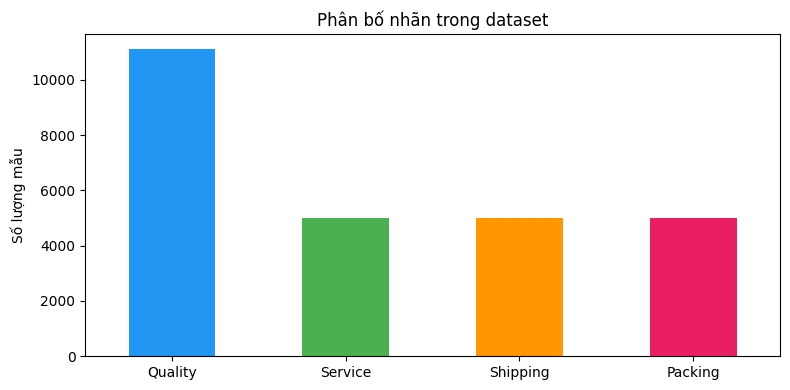

In [8]:
label_cols = ['Quality', 'Service', 'Shipping', 'Packing']

print('Phân bố nhãn:')
for col in label_cols:
    count = df[col].sum()
    print(f'  {col}: {count} ({count/len(df)*100:.1f}%)')

df[label_cols].sum().plot(
    kind='bar',
    color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63'],
    figsize=(8, 4)
)
plt.title('Phân bố nhãn trong dataset')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Chuyển Đổi Nhãn

4 cột nhị phân → 1 cột integer (multi-class):
- Quality → 0
- Service → 1
- Packing → 2
- Shipping → 3

In [9]:
label_map = {'Quality': 0, 'Service': 1, 'Packing': 2, 'Shipping': 3}
inverse_label_map = {v: k for k, v in label_map.items()}

df['label'] = df[label_cols].idxmax(axis=1).map(label_map)

# Verify: mỗi hàng có đúng 1 cột bằng 1
assert (df[label_cols].sum(axis=1) == 1).all(), 'ERROR: Dữ liệu không phải single-label!'
print('Kiểm tra single-label: OK')
print('\nPhân bố sau chuyển đổi:')
print(df['label'].value_counts().sort_index().rename(inverse_label_map))

Kiểm tra single-label: OK

Phân bố sau chuyển đổi:
label
Quality     11110
Service      5000
Packing      5000
Shipping     5000
Name: count, dtype: int64


## Tiền Xử Lý Text

In [10]:
print('Đang tiền xử lý văn bản (vài phút)...')
df['content_clean'] = df['content'].apply(preprocess_comment)

before = len(df)
df = df[df['content_clean'].notna()].reset_index(drop=True)
after = len(df)
print(f'Đã loại {before - after} dòng không hợp lệ.')
print(f'Số mẫu sau tiền xử lý: {after}')
df[['content', 'content_clean', 'label']].head()

Đang tiền xử lý văn bản (vài phút)...
Đã loại 0 dòng không hợp lệ.
Số mẫu sau tiền xử lý: 26110


,content,content_clean,label
0,size chật không cho đổi sản phẩm mình không hà...,cỡ chật đổi sản phẩm hài,0
1,sóng 5g phát tốc độ chậm hơn 1 nửa so với tốc ...,sóng 5g phát tốc độ chậm 1 nửa tốc độ sóng 5g ...,0
2,sài một chút là bị lún xuống dễ bám bụi khó vệ...,sài chút lún bám bụi vệ sinh,0
3,"nhầm mẫu, không đẹp! nhận đại",nhầm mẫu đẹp đại,3
4,"bao bọc sản phẩm xộc xệch, cảm giác không được...",bao bọc sản phẩm xộc xệch cảm giác tôn trọng s...,2


## Hyperparameters

In [11]:
# DL hyperparameters
NUM_WORDS      = 8000   # phủ 96.9% vocabulary thực tế (8,261 từ)
EMBEDDING_DIM  = 48     # tăng từ 32 → 48: thêm capacity (32 quá nhỏ)
MAXLEN         = 120
PADDING        = 'post'
OOV_TOKEN      = '<OOV>'
TRAINING_SPLIT = 0.85   # tăng từ 0.8 → 0.85: thêm dữ liệu train cho DL
NUM_CLASSES    = 4

print(f'NUM_WORDS={NUM_WORDS}, EMBEDDING_DIM={EMBEDDING_DIM}, MAXLEN={MAXLEN}')
print(f'TRAINING_SPLIT={TRAINING_SPLIT}')

NUM_WORDS=8000, EMBEDDING_DIM=48, MAXLEN=120
TRAINING_SPLIT=0.85


---
# Machine Learning Models (TF-IDF)

Pipeline: `content_clean` → `TfidfVectorizer` → Classifier

In [12]:
X = df['content_clean']
y_str = df[label_cols].idxmax(axis=1)   # string labels: 'Quality', 'Service', ...
y_int = df['label']                      # integer labels: 0, 1, 2, 3

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y_str, test_size=0.2, random_state=42
)

# ngram_range=(1,2): bắt bigram — giúp nhận diện cụm từ như "giao hàng chậm", "đóng gói kỹ"
# sublinear_tf=True: giảm ảnh hưởng của từ xuất hiện quá nhiều
tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f'Train: {len(X_train_ml)} mẫu | Test: {len(X_test_ml)} mẫu')
print(f'TF-IDF features: {X_train_tfidf.shape[1]}')

Train: 20888 mẫu | Test: 5222 mẫu
TF-IDF features: 84900


### 1. Random Forest

In [13]:
print('Training Random Forest...')
# class_weight='balanced': bù mất cân bằng nhãn (Quality 42.6% vs các nhãn kia ~19%)
# n_estimators=200: tăng độ ổn định
rf_classifier = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_classifier.fit(X_train_tfidf, y_train_ml)

rf_pred = rf_classifier.predict(X_test_tfidf)
rf_acc  = accuracy_score(y_test_ml, rf_pred)
rf_prec = precision_score(y_test_ml, rf_pred, average='weighted')
rf_rec  = recall_score(y_test_ml, rf_pred, average='weighted')
rf_f1   = f1_score(y_test_ml, rf_pred, average='weighted')

print(f'\nRandom Forest Results:')
print(f'  Accuracy:  {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'  Precision: {rf_prec:.4f}')
print(f'  Recall:    {rf_rec:.4f}')
print(f'  F1 Score:  {rf_f1:.4f}')
print()
print(classification_report(y_test_ml, rf_pred))

Training Random Forest...

Random Forest Results:
  Accuracy:  0.9127 (91.27%)
  Precision: 0.9132
  Recall:    0.9127
  F1 Score:  0.9126

              precision    recall  f1-score   support

     Packing       0.95      0.98      0.97      1000
     Quality       0.93      0.90      0.91      2185
     Service       0.87      0.86      0.87      1036
    Shipping       0.88      0.93      0.90      1001

    accuracy                           0.91      5222
   macro avg       0.91      0.92      0.91      5222
weighted avg       0.91      0.91      0.91      5222



### 2. Support Vector Machine (SVM)

In [14]:
print('Training SVM...')
svm_classifier = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_classifier.fit(X_train_tfidf, y_train_ml)

svm_pred = svm_classifier.predict(X_test_tfidf)
svm_acc  = accuracy_score(y_test_ml, svm_pred)
svm_prec = precision_score(y_test_ml, svm_pred, average='weighted')
svm_rec  = recall_score(y_test_ml, svm_pred, average='weighted')
svm_f1   = f1_score(y_test_ml, svm_pred, average='weighted')

print(f'\nSVM Results:')
print(f'  Accuracy:  {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'  Precision: {svm_prec:.4f}')
print(f'  Recall:    {svm_rec:.4f}')
print(f'  F1 Score:  {svm_f1:.4f}')
print()
print(classification_report(y_test_ml, svm_pred))

Training SVM...

SVM Results:
  Accuracy:  0.9136 (91.36%)
  Precision: 0.9151
  Recall:    0.9136
  F1 Score:  0.9135

              precision    recall  f1-score   support

     Packing       0.94      0.99      0.96      1000
     Quality       0.95      0.88      0.91      2185
     Service       0.86      0.88      0.87      1036
    Shipping       0.87      0.95      0.91      1001

    accuracy                           0.91      5222
   macro avg       0.91      0.92      0.91      5222
weighted avg       0.92      0.91      0.91      5222



### 3. Logistic Regression

In [15]:
print('Training Logistic Regression...')
lr_classifier = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_classifier.fit(X_train_tfidf, y_train_ml)

lr_pred = lr_classifier.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test_ml, lr_pred)
lr_prec = precision_score(y_test_ml, lr_pred, average='weighted')
lr_rec  = recall_score(y_test_ml, lr_pred, average='weighted')
lr_f1   = f1_score(y_test_ml, lr_pred, average='weighted')

print(f'\nLogistic Regression Results:')
print(f'  Accuracy:  {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print(f'  Precision: {lr_prec:.4f}')
print(f'  Recall:    {lr_rec:.4f}')
print(f'  F1 Score:  {lr_f1:.4f}')
print()
print(classification_report(y_test_ml, lr_pred))

Training Logistic Regression...

Logistic Regression Results:
  Accuracy:  0.8995 (89.95%)
  Precision: 0.9011
  Recall:    0.8995
  F1 Score:  0.8995

              precision    recall  f1-score   support

     Packing       0.93      0.98      0.95      1000
     Quality       0.94      0.87      0.90      2185
     Service       0.84      0.86      0.85      1036
    Shipping       0.86      0.92      0.89      1001

    accuracy                           0.90      5222
   macro avg       0.89      0.91      0.90      5222
weighted avg       0.90      0.90      0.90      5222



In [16]:
pickle.dump(rf_classifier,  open('/kaggle/working/rf_classifier.pkl',     'wb'))
pickle.dump(svm_classifier, open('/kaggle/working/svm_classifier.pkl',    'wb'))
pickle.dump(lr_classifier,  open('/kaggle/working/lr_classifier.pkl',     'wb'))
pickle.dump(tfidf,          open('/kaggle/working/tfidf_vectorizer.pkl',  'wb'))
print('ML models saved to /kaggle/working/')

ML models saved to /kaggle/working/


---
# Deep Learning Models (Embedding + Sequences)

Pipeline: `content_clean` → `Tokenizer` → `pad_sequences` → Neural Network

In [17]:
sentences = df['content_clean'].tolist()
labels    = df['label'].values

train_size = int(len(sentences) * TRAINING_SPLIT)
train_sentences = sentences[:train_size]
val_sentences   = sentences[train_size:]
train_labels    = labels[:train_size]
val_labels      = labels[train_size:]

tokenizer_dl = Tokenizer(num_words=NUM_WORDS, oov_token=OOV_TOKEN)
tokenizer_dl.fit_on_texts(train_sentences)
VOCAB_SIZE = len(tokenizer_dl.word_index)

train_padded = pad_sequences(tokenizer_dl.texts_to_sequences(train_sentences),
                             maxlen=MAXLEN, padding=PADDING)
val_padded   = pad_sequences(tokenizer_dl.texts_to_sequences(val_sentences),
                             maxlen=MAXLEN, padding=PADDING)

print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Train shape: {train_padded.shape} | Val shape: {val_padded.shape}')
print(f'Train labels: {train_labels.shape} | Val labels: {val_labels.shape}')

Vocabulary size: 8478
Train shape: (22193, 120) | Val shape: (3917, 120)
Train labels: (22193,) | Val labels: (3917,)


In [18]:
pickle.dump(tokenizer_dl, open('/kaggle/working/tokenizer.pkl', 'wb'))
print('Tokenizer saved.')


def plot_graphs(history, metric):
    plt.plot(history.history[metric], label='Train')
    plt.plot(history.history['val_' + metric], label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.title(metric)
    plt.show()


def get_callbacks(model_name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=8,                    # giảm từ 10→8: dừng sớm hơn
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=6,                    # tăng từ 4→6: val_loss nhiễu, tránh giảm LR quá sớm
            min_lr=1e-6,
            verbose=1
        )
    ]

Tokenizer saved.


### 4. LSTM

In [19]:
# V10 FIX: V9 (mask_zero=True) lam KERNEL CRASH (loi cuDNN mask
# assertion), khong chi khong fix duoc 41.72% degenerate ma con mat luon
# ket qua GRU/CNN. Day la lan thu 5 lien tiep (V5-V9) LSTM that bai.
# QUYET DINH: quay ve kien truc LSTM nguyen ban cua V4 - phien ban DUY
# NHAT LSTM hoat dong dung (90.54%, gap overfit hop ly 8.1%).
# So voi V6 (gan giong nhat nhung that bai): bo SpatialDropout1D (dung
# Dropout thuong), bo L2 tren Conv1D/Dense, bo Dense(32) trung gian,
# dung optimizer='adam' mac dinh (lr=1e-3, khong clipnorm).
def create_model_LSTM(vocab_size, embedding_dim, maxlen):
    tf.random.set_seed(123)
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size + 1, embedding_dim,
                                  input_length=maxlen, trainable=True),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Conv1D(64, 5, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=4),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_LSTM = create_model_LSTM(VOCAB_SIZE, EMBEDDING_DIM, MAXLEN)
model_LSTM.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1781203092.849276     114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781203092.855367     114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_LSTM = model_LSTM.fit(
    train_padded, train_labels,
    epochs=50,
    validation_data=(val_padded, val_labels),
    callbacks=get_callbacks('LSTM'),
    verbose=1
)


Epoch 1/50


I0000 00:00:1781203097.966054     187 cuda_dnn.cc:529] Loaded cuDNN version 91002


694/694 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4724 - loss: 1.1975 - val_accuracy: 0.5264 - val_loss: 1.1344 - learning_rate: 0.0010
Epoch 2/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5275 - loss: 1.0511 - val_accuracy: 0.5504 - val_loss: 0.9656 - learning_rate: 0.0010
Epoch 3/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5571 - loss: 0.9096 - val_accuracy: 0.5591 - val_loss: 0.9274 - learning_rate: 0.0010
Epoch 4/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5751 - loss: 0.8555 - val_accuracy: 0.5622 - val_loss: 0.9138 - learning_rate: 0.0010
Epoch 5/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5893 - loss: 0.8313 - val_accuracy: 0.5729 - val_loss: 0.9172 - learning_rate: 0.0010
Epoch 6/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6301 - loss: 0.7802 - val_accuracy: 0.7215 - val_loss: 0.7167 - learning_rate: 0.0010
Epoch 7/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8214 - loss: 0.4874 - val_accura

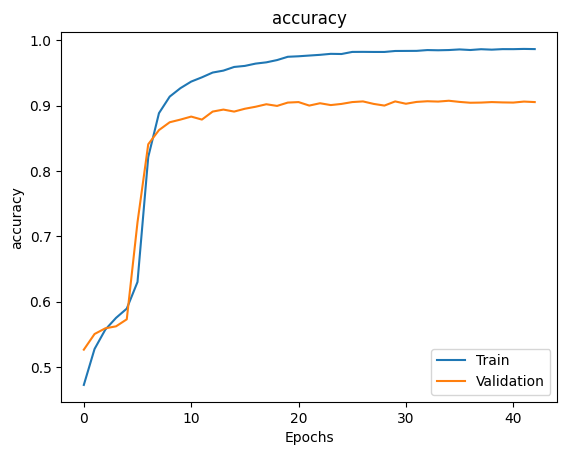

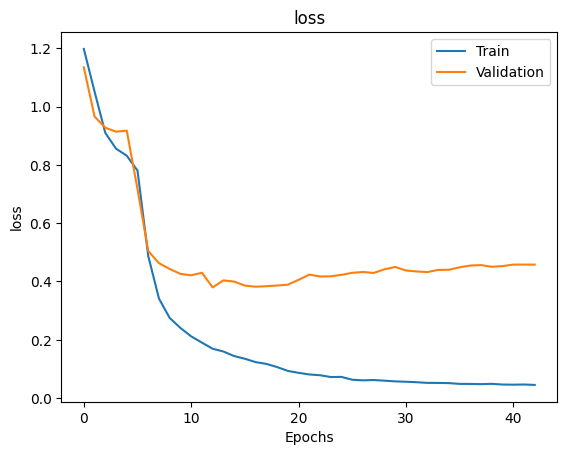

LSTM Test Accuracy: 0.9076 (90.76%)
LSTM model saved.


In [21]:
plot_graphs(history_LSTM, 'accuracy')
plot_graphs(history_LSTM, 'loss')

lstm_loss, lstm_acc = model_LSTM.evaluate(val_padded, val_labels, verbose=0)
print(f'LSTM Test Accuracy: {lstm_acc:.4f} ({lstm_acc*100:.2f}%)')

model_LSTM.save('/kaggle/working/LSTM.model.h5')
print('LSTM model saved.')

### 5. GRU (Bidirectional)

In [22]:
def create_model_GRU(vocab_size, embedding_dim, maxlen):
    tf.random.set_seed(123)
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size + 1, embedding_dim,
                                  input_length=maxlen, trainable=True),
        tf.keras.layers.SpatialDropout1D(0.3),
        tf.keras.layers.Bidirectional(
            tf.keras.layers.GRU(64)
        ),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu',
                              kernel_regularizer=l2(0.0005)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_GRU = create_model_GRU(VOCAB_SIZE, EMBEDDING_DIM, MAXLEN)
model_GRU.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_GRU = model_GRU.fit(
    train_padded, train_labels,
    epochs=80,  # tăng lên 80: GRU chưa hội tụ ở epoch 30
    validation_data=(val_padded, val_labels),
    callbacks=get_callbacks('GRU'),
    verbose=1
)

Epoch 1/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7624 - loss: 0.6777 - val_accuracy: 0.8570 - val_loss: 0.4453 - learning_rate: 0.0010
Epoch 2/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8739 - loss: 0.4032 - val_accuracy: 0.8744 - val_loss: 0.3903 - learning_rate: 0.0010
Epoch 3/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9020 - loss: 0.3247 - val_accuracy: 0.8815 - val_loss: 0.3706 - learning_rate: 0.0010
Epoch 4/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9179 - loss: 0.2732 - val_accuracy: 0.8864 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 5/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9284 - loss: 0.2435 - val_accuracy: 0.8920 - val_loss: 0.3649 - learning_rate: 0.0010
Epoch 6/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9378 - loss: 0.2176 - val_accuracy: 0.8963 - val_loss: 0.3663 - learning_rate: 0.0010
Epoch 7/80
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9428 - l

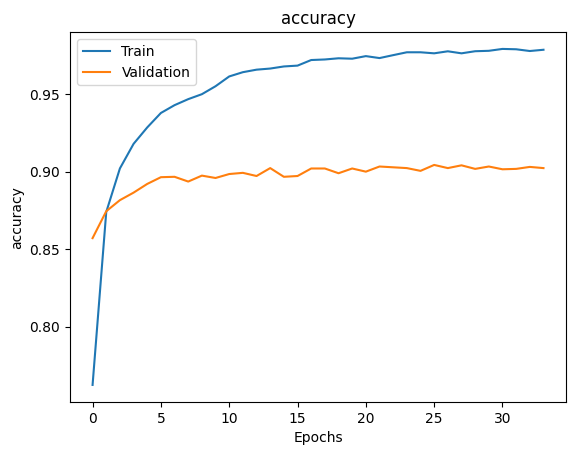

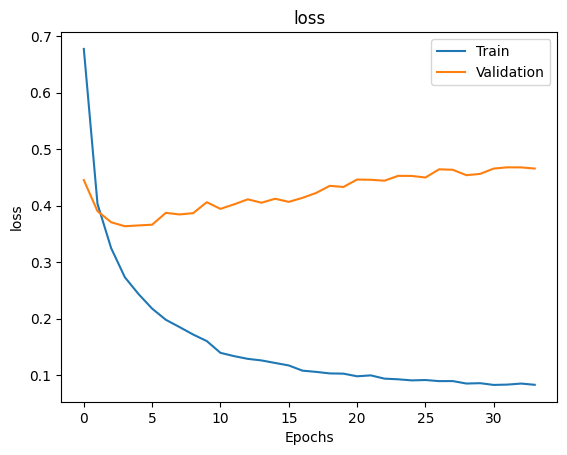

GRU Test Accuracy: 0.9043 (90.43%)
GRU model saved.


In [24]:
plot_graphs(history_GRU, 'accuracy')
plot_graphs(history_GRU, 'loss')

gru_loss, gru_acc = model_GRU.evaluate(val_padded, val_labels, verbose=0)
print(f'GRU Test Accuracy: {gru_acc:.4f} ({gru_acc*100:.2f}%)')

model_GRU.save('/kaggle/working/GRU.model.h5')
print('GRU model saved.')

### 6. CNN (Conv1D)

In [25]:
def create_model_conv(vocab_size, embedding_dim, maxlen):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size + 1, embedding_dim,
                                  input_length=maxlen, trainable=True),
        tf.keras.layers.SpatialDropout1D(0.3),
        tf.keras.layers.Conv1D(128, 5, activation='relu',
                               kernel_regularizer=l2(0.0005)),
        tf.keras.layers.GlobalMaxPooling1D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu',
                              kernel_regularizer=l2(0.0005)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_conv = create_model_conv(VOCAB_SIZE, EMBEDDING_DIM, MAXLEN)
model_conv.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
history_conv = model_conv.fit(
    train_padded, train_labels,
    epochs=50,
    validation_data=(val_padded, val_labels),
    callbacks=get_callbacks('CNN'),
    verbose=1
)

Epoch 1/50


I0000 00:00:1781203721.431194     186 service.cc:152] XLA service 0x78e7b82a9a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781203721.431273     186 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781203721.431281     186 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 47/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3892 - loss: 1.4099

I0000 00:00:1781203724.624918     186 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


694/694 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7595 - loss: 0.7051 - val_accuracy: 0.8637 - val_loss: 0.4551 - learning_rate: 0.0010
Epoch 2/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8773 - loss: 0.4374 - val_accuracy: 0.8805 - val_loss: 0.4114 - learning_rate: 0.0010
Epoch 3/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9018 - loss: 0.3684 - val_accuracy: 0.8874 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 4/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9188 - loss: 0.3205 - val_accuracy: 0.8920 - val_loss: 0.3880 - learning_rate: 0.0010
Epoch 5/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9307 - loss: 0.2804 - val_accuracy: 0.8966 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 6/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9402 - loss: 0.2518 - val_accuracy: 0.8994 - val_loss: 0.3886 - learning_rate: 0.0010
Epoch 7/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9456 - loss: 0.2351 - val_accur

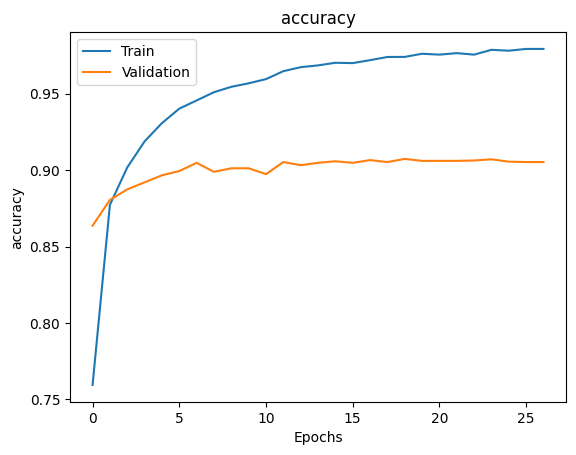

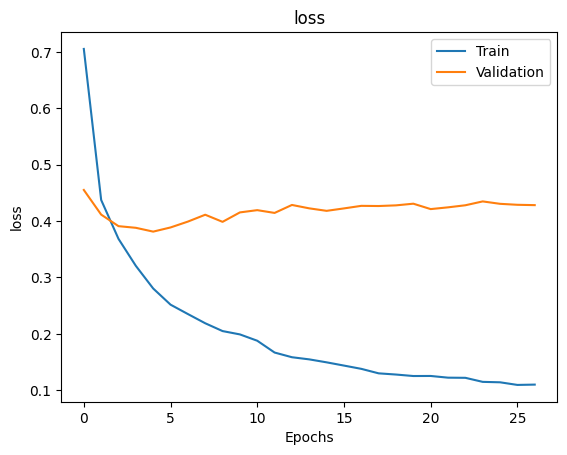

CNN Test Accuracy: 0.9073 (90.73%)
CNN model saved.


In [27]:
plot_graphs(history_conv, 'accuracy')
plot_graphs(history_conv, 'loss')

cnn_loss, cnn_acc = model_conv.evaluate(val_padded, val_labels, verbose=0)
print(f'CNN Test Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')

model_conv.save('/kaggle/working/conv.model.h5')
print('CNN model saved.')

---
## So Sánh Kết Quả 6 Mô Hình

In [28]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'LSTM', 'GRU', 'CNN'],
    'Type':  ['ML', 'ML', 'ML', 'DL', 'DL', 'DL'],
    'Accuracy': [
        f'{rf_acc*100:.2f}%',
        f'{svm_acc*100:.2f}%',
        f'{lr_acc*100:.2f}%',
        f'{lstm_acc*100:.2f}%',
        f'{gru_acc*100:.2f}%',
        f'{cnn_acc*100:.2f}%'
    ],
    'Precision': [f'{rf_prec:.4f}', f'{svm_prec:.4f}', f'{lr_prec:.4f}', '-', '-', '-'],
    'Recall':    [f'{rf_rec:.4f}',  f'{svm_rec:.4f}',  f'{lr_rec:.4f}',  '-', '-', '-'],
    'F1 Score':  [f'{rf_f1:.4f}',   f'{svm_f1:.4f}',   f'{lr_f1:.4f}',   '-', '-', '-'],
})
print(results.to_string(index=False))

              Model Type Accuracy Precision Recall F1 Score
      Random Forest   ML   91.27%    0.9132 0.9127   0.9126
                SVM   ML   91.36%    0.9151 0.9136   0.9135
Logistic Regression   ML   89.95%    0.9011 0.8995   0.8995
               LSTM   DL   90.76%         -      -        -
                GRU   DL   90.43%         -      -        -
                CNN   DL   90.73%         -      -        -


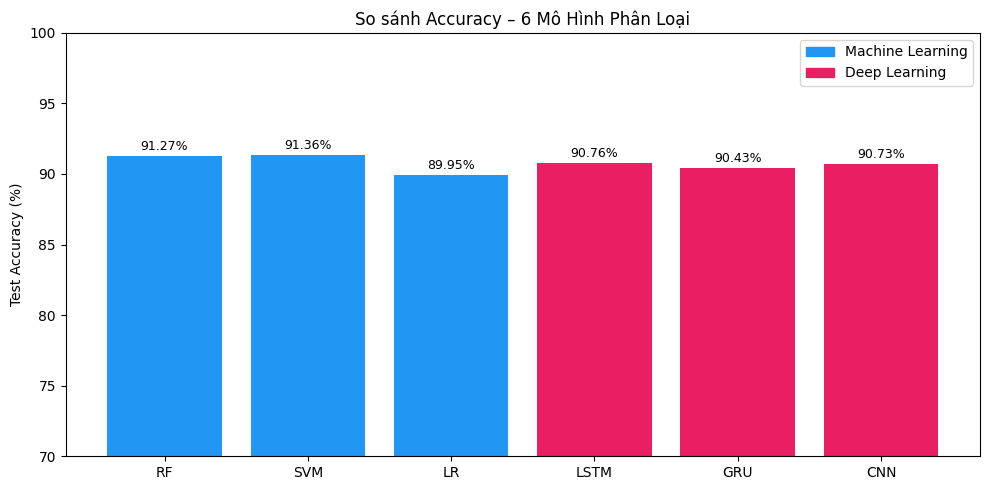

In [29]:
model_names = ['RF', 'SVM', 'LR', 'LSTM', 'GRU', 'CNN']
accuracies  = [rf_acc, svm_acc, lr_acc, lstm_acc, gru_acc, cnn_acc]
colors      = ['#2196F3', '#2196F3', '#2196F3', '#E91E63', '#E91E63', '#E91E63']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies], color=colors)
plt.ylabel('Test Accuracy (%)')
plt.title('So sánh Accuracy – 6 Mô Hình Phân Loại')
plt.ylim(70, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=9)
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color='#2196F3', label='Machine Learning'),
        plt.Rectangle((0, 0), 1, 1, color='#E91E63', label='Deep Learning')
    ]
)
plt.tight_layout()
plt.show()

In [30]:
print('\nCác model đã lưu tại /kaggle/working/:')
for fname in sorted(os.listdir('/kaggle/working/')):
    size_kb = os.path.getsize(f'/kaggle/working/{fname}') / 1024
    print(f'  {fname:<35} ({size_kb:.1f} KB)')


Các model đã lưu tại /kaggle/working/:
  .virtual_documents                  (4.0 KB)
  GRU.model.h5                        (5383.5 KB)
  LSTM.model.h5                       (5380.1 KB)
  conv.model.h5                       (5219.7 KB)
  lr_classifier.pkl                   (2653.9 KB)
  rf_classifier.pkl                   (235851.5 KB)
  svm_classifier.pkl                  (3187.7 KB)
  tfidf_vectorizer.pkl                (2043.4 KB)
  tokenizer.pkl                       (315.5 KB)
